# NDT7 PH — Paper Support Analysis

เล่มนี้แยกจาก `ndt7_ph_main.ipynb` (EDA ทั่วไป) โดยเฉพาะสำหรับตอบคำถามที่ paper ต้องใช้ตรง ๆ
เริ่มจาก **แนวโน้มความเร็วอินเทอร์เน็ตระดับประเทศตามเวลา** (fixed broadband vs mobile/cellular)

ใช้ข้อมูลเดียวกับ `ndt7_ph_main.ipynb`: `data/ph/mlab_ph_clean.parquet`

## Part 0 · Setup

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- resolve repo root regardless of the kernel's working dir ---
ROOT = Path.cwd()
while not (ROOT / 'data' / 'ph').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CLEAN = ROOT / 'data' / 'ph' / 'mlab_ph_clean.parquet'
assert CLEAN.exists(), f'missing {CLEAN}'

con = duckdb.connect()
con.execute("SET max_memory='12GB'")
con.execute(f"SET temp_directory='{(ROOT / '.tmp').as_posix()}'")

# same monitoring/bot IP excluded in ndt7_ph_main.ipynb (865k tests, all SultanKudarat) --
# kept out here too so national numbers line up with the main EDA notebook
FLOOD_IPS = ('58.69.220.245',)
_flood = ', '.join(f"'{ip}'" for ip in FLOOD_IPS)
con.execute(f"CREATE OR REPLACE VIEW t AS SELECT * FROM read_parquet('{CLEAN.as_posix()}') "
            f"WHERE client_ip NOT IN ({_flood})")

def q(sql):
    return con.execute(sql).df()

FIXED  = "network_type = 'broadband'"
MOBILE = "network_type = 'cellular'"
DL     = "type = 'download'"

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
C_FIXED, C_MOBILE = '#0B6E5C', '#B8571F'

n_rows = con.execute("SELECT COUNT(*) FROM t").fetchone()[0]
print(f'ROOT : {ROOT}')
print(f'CLEAN: {CLEAN.name} ({n_rows:,} rows, flood IP excluded)')

ROOT : E:\ndt7
CLEAN: mlab_ph_clean.parquet (261,245,709 rows, flood IP excluded)


# Part 1 · แนวโน้มความเร็ว download ระดับประเทศ รายไตรมาส (2023 Q1 → 2025 Q4)

Time series ราย**ไตรมาส**ทั้ง 12 ไตรมาส แยก **fixed broadband vs mobile/cellular** — ทำทั้ง mean (ไวต่อ
connection เร็ว ๆ ที่เพิ่มเข้ามา) และ median (สะท้อนผู้ใช้ทั่วไป) เพื่อดูว่าเน็ตทั้งประเทศ "โต" จริงไหมและโตแบบไหน

- แกน x = ไตรมาส 2023Q1–2025Q4 (12 จุด) · แกน y = ความเร็ว download (Mbps)
- ตัวเลขบนจุดสุดท้ายของแต่ละเส้น = ค่า ณ 2025 Q4 (ใช้เทียบ endpoint growth ได้ตรงกับ Part 6 ของ `ndt7_ph_main.ipynb`)

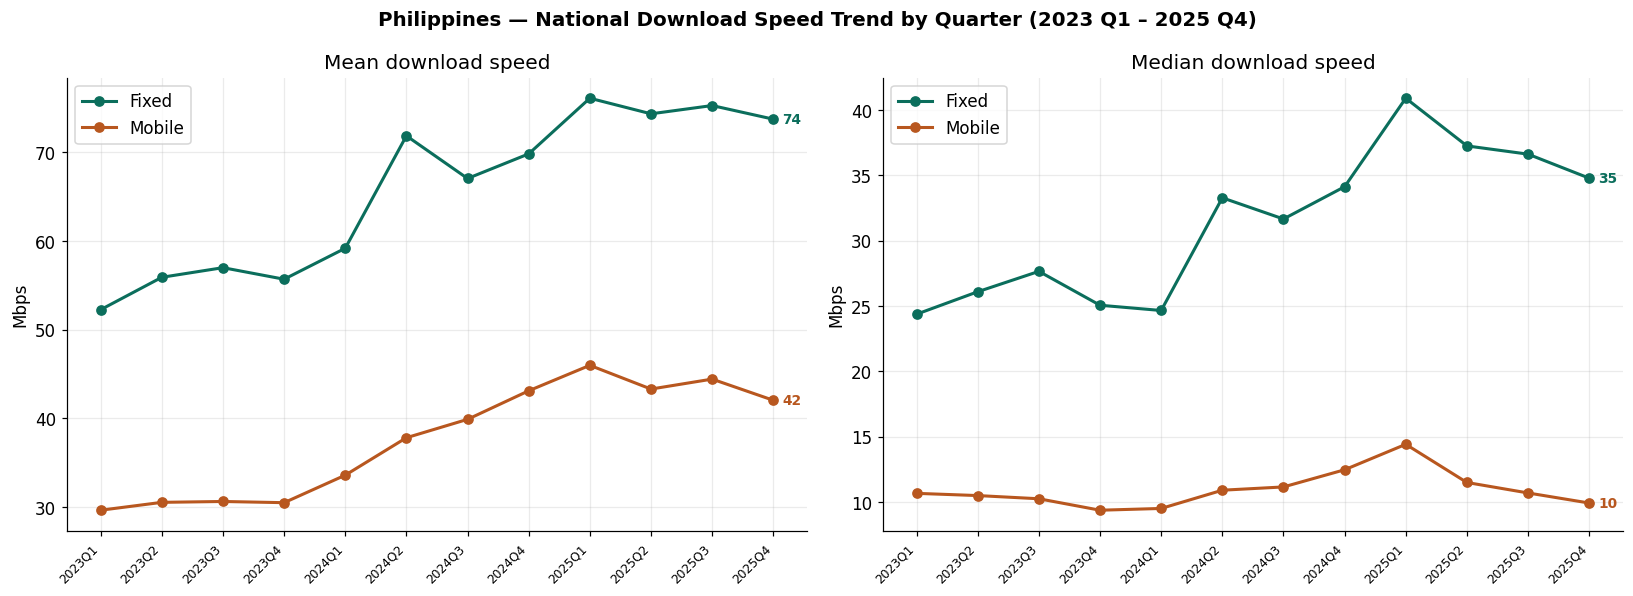

n            mean_dl        median_dl       
segment       Fixed     Mobile   Fixed Mobile     Fixed Mobile
qlabel                                                        
2023Q1    7273697.0  3868279.0    52.3   29.6      24.4   10.7
2023Q2    7261804.0  3847141.0    55.9   30.5      26.1   10.5
2023Q3    7784344.0  4484566.0    57.0   30.6      27.6   10.2
2023Q4    6312691.0  4035789.0    55.7   30.5      25.1    9.4
2024Q1    6789376.0  4188376.0    59.2   33.6      24.7    9.5
2024Q2    7334236.0  4411668.0    71.9   37.8      33.3   10.9
2024Q3    7410766.0  4882243.0    67.1   39.9      31.7   11.1
2024Q4    6504558.0  4812694.0    69.8   43.1      34.1   12.5
2025Q1   10059853.0  5945405.0    76.1   46.0      40.9   14.4
2025Q2    7414154.0  4913963.0    74.4   43.3      37.3   11.5
2025Q3    8554795.0  5361884.0    75.3   44.4      36.6   10.7
2025Q4    8237767.0  5233511.0    73.7   42.0      34.8    9.9

In [2]:
trend = q(f"""
    SELECT year,
           CAST(CEIL(month / 3.0) AS INT) AS quarter,
           CASE WHEN {FIXED} THEN 'Fixed' ELSE 'Mobile' END AS segment,
           COUNT(*)                              AS n,
           AVG(mean_throughput_mbps)              AS mean_dl,
           MEDIAN(mean_throughput_mbps)            AS median_dl
    FROM t
    WHERE {DL} AND ({FIXED} OR {MOBILE})
    GROUP BY 1, 2, 3
    ORDER BY 1, 2
""")
trend['qlabel'] = trend['year'].astype(str) + 'Q' + trend['quarter'].astype(str)
quarters = sorted(trend['qlabel'].unique(), key=lambda s: (int(s[:4]), int(s[5])))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
for ax, col, ttl in [(a1, 'mean_dl', 'Mean download speed'), (a2, 'median_dl', 'Median download speed')]:
    for seg, color in [('Fixed', C_FIXED), ('Mobile', C_MOBILE)]:
        d = trend[trend.segment == seg].set_index('qlabel').reindex(quarters)
        ax.plot(quarters, d[col], marker='o', color=color, label=seg, lw=2)
        last = d[col].iloc[-1]
        ax.annotate(f'{last:.0f}', (len(quarters) - 1, last), textcoords='offset points',
                    xytext=(6, 0), va='center', color=color, fontsize=9, fontweight='bold')
    ax.set_title(ttl)
    ax.set_ylabel('Mbps')
    ax.set_xticks(range(len(quarters)))
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=8)
    ax.legend(loc='upper left')

fig.suptitle('Philippines — National Download Speed Trend by Quarter (2023 Q1 – 2025 Q4)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

trend.pivot(index='qlabel', columns='segment', values=['n', 'mean_dl', 'median_dl']).loc[quarters].round(1)

# Part 2 · แนวโน้ม/ระดับความเร็ว รายภูมิภาค (17 regions — ไม่ใช่ island)

จาก Part 1 ที่ดูภาพรวมประเทศ ซูมลงมาราย **17 ภูมิภาค (region)** เพื่อดูว่าตัวเลขระดับประเทศบัง variation ระหว่าง
ภูมิภาคไว้แค่ไหน — ใช้ `region` column ที่มากับ parquet ตรงๆ (17 หน่วย: NCR, CAR, Region I–XIII, BARMM,
MIMAROPA) แล้ว map ต่อไปยัง 3 หมู่เกาะ (`island`: Luzon/Visayas/Mindanao) **เพื่อระบายสีแท่งเท่านั้น** —
แกน y ของกราฟยังเป็น region 17 หน่วยเสมอ ไม่ใช่ island — เดียวกับที่ `ndt7_ph_main.ipynb` Part 2–3 ใช้

> ลำดับชั้นพื้นที่ในเล่มนี้: `province` (81, ADM1 — Part 7-9) ⊂ `region` (17 — เล่มนี้) ⊂ `island` (3, สีเท่านั้น
> ไม่มีกราฟไหนใช้เป็นแกน)

metric: ค่าเฉลี่ยราย region *ต่อไตรมาส* แล้วเฉลี่ยข้าม 12 ไตรมาส (2023 Q1 – 2025 Q4) เพื่อไม่ให้ปี 2025
ที่มี test เยอะกลบปีอื่น

In [3]:
import sys
from matplotlib.patches import Patch

# --- region -> island group, imported from a single shared source (not redefined per
# notebook) so ndt7_ph_main.ipynb and ndt7_ph_paper.ipynb can never drift apart. ---
sys.path.insert(0, str(ROOT / 'ip_fetch' / 'srs'))
from ph_island_map import REGION_TO_ISLAND as ISLAND, ISLAND_COLORS

reg_map = q("""
    SELECT DISTINCT province, region
    FROM t
    WHERE province IS NOT NULL AND region IS NOT NULL
""")
_missing = sorted(set(reg_map['region']) - set(ISLAND))
assert not _missing, f'region(s) not in the ISLAND map: {_missing}'
reg_map['island'] = reg_map['region'].map(ISLAND)
con.register('reg_map', reg_map)

print(f'reg_map: {len(reg_map)} provinces -> {reg_map.region.nunique()} regions -> {reg_map.island.nunique()} islands')

reg_map: 80 provinces -> 17 regions -> 3 islands


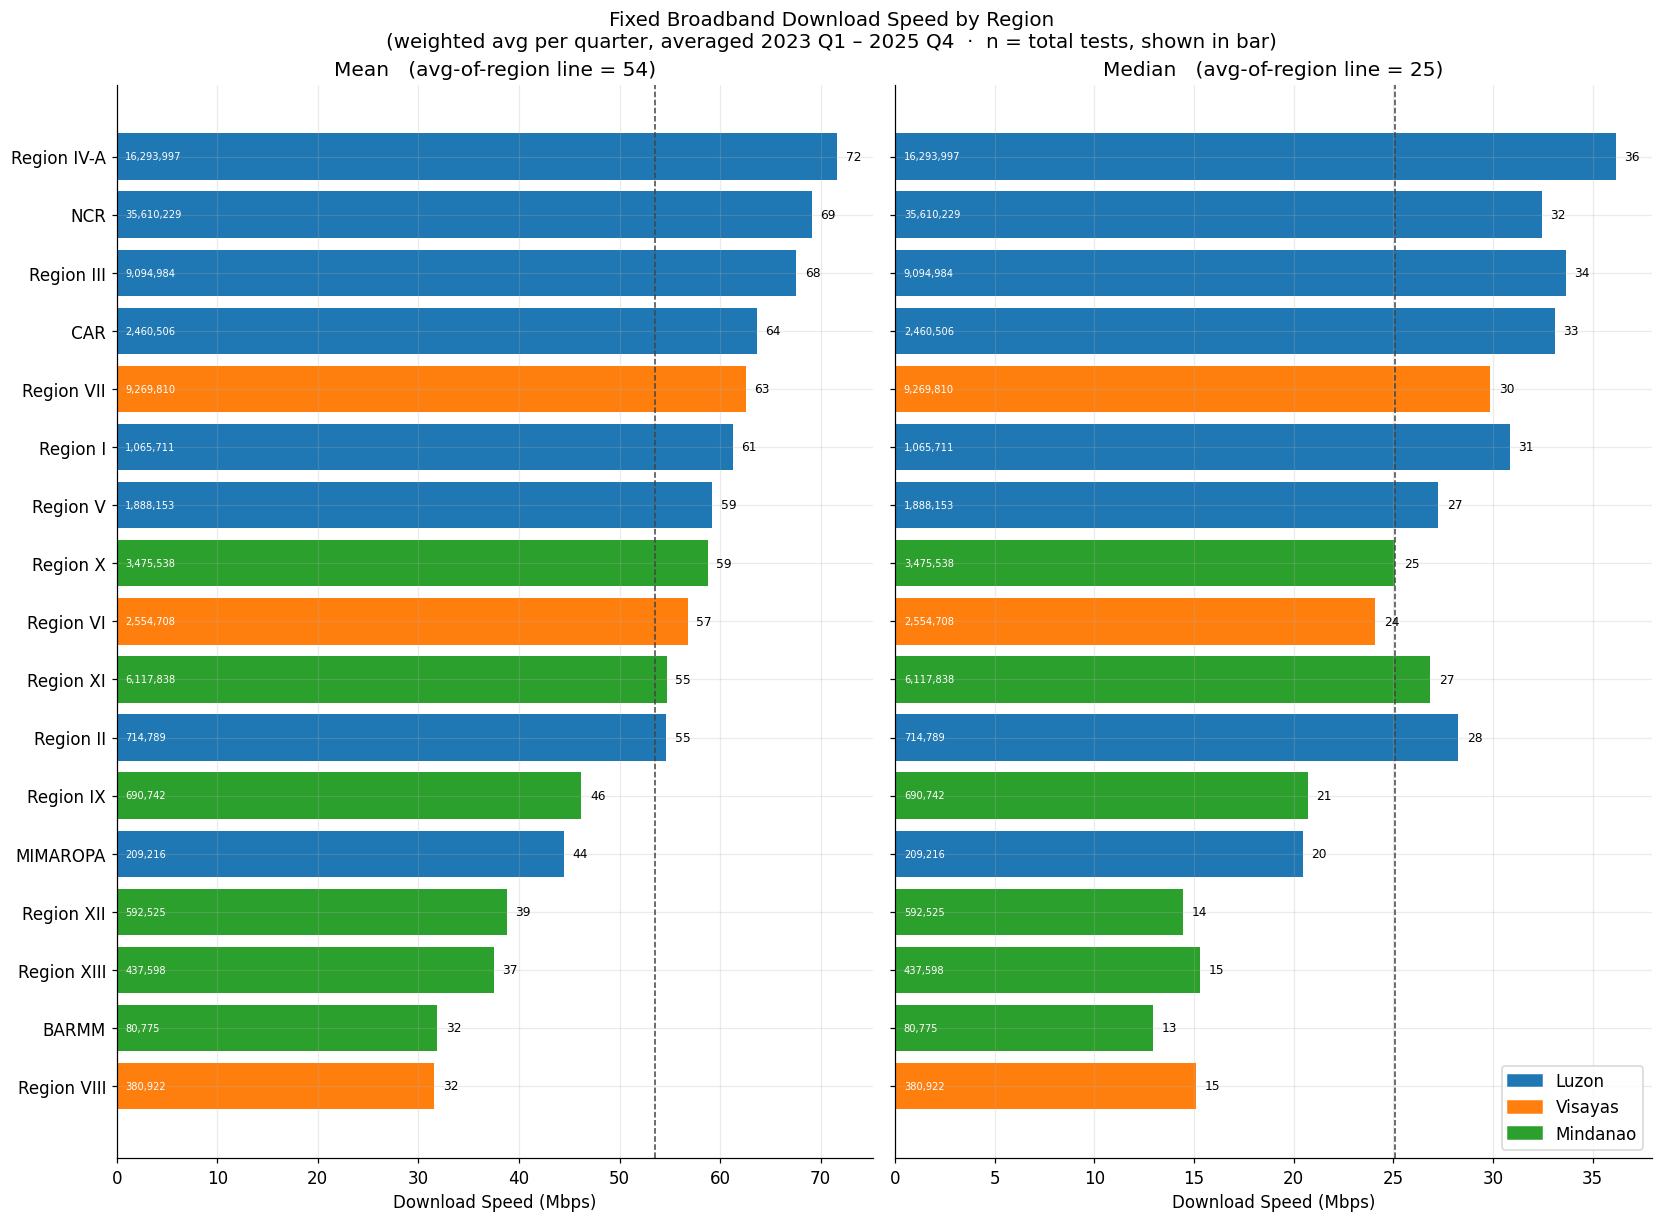

In [4]:
def region_speed_figure(net_pred, seg_label):
    """Region bar chart (mean | median panels) for one network type.
    metric = per-region test-weighted average per quarter, then averaged across all
    quarters 2023Q1-2025Q4; n (in bar) = total tests; dashed line = mean across regions."""
    agg = q(f"""
        WITH rq AS (
            SELECT m.region, m.island, t.year, CAST(CEIL(t.month/3.0) AS INT) AS quarter,
                   AVG(t.mean_throughput_mbps)    AS q_mean,
                   MEDIAN(t.mean_throughput_mbps) AS q_median,
                   COUNT(*)                       AS q_n
            FROM t JOIN reg_map m ON t.province = m.province
            WHERE {net_pred} AND {DL}
            GROUP BY 1, 2, 3, 4
        )
        SELECT region, island,
               AVG(q_mean)   AS mean_spd,
               AVG(q_median) AS median_spd,
               SUM(q_n)      AS total_tests
        FROM rq GROUP BY 1, 2
    """).sort_values('mean_spd').reset_index(drop=True)

    y = np.arange(len(agg))
    cols = [ISLAND_COLORS[i] for i in agg['island']]
    fig, axes = plt.subplots(1, 2, figsize=(15, 11), sharey=True, constrained_layout=True)
    for ax, mcol, ttl in [(axes[0], 'mean_spd', 'Mean'), (axes[1], 'median_spd', 'Median')]:
        ax.barh(y, agg[mcol], color=cols)
        ref, mx = agg[mcol].mean(), agg[mcol].max()
        ax.axvline(ref, ls='--', color='#444', lw=1)
        for yi, v, n in zip(y, agg[mcol], agg['total_tests']):
            ax.text(v + mx * 0.012, yi, f'{v:.0f}', va='center', fontsize=8)
            ax.text(mx * 0.012, yi, f'{n:,.0f}', va='center', fontsize=6.5, color='white')
        ax.set_title(f'{ttl}   (avg-of-region line = {ref:.0f})')
        ax.set_xlabel('Download Speed (Mbps)')
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(agg['region'])
    axes[1].legend(handles=[Patch(color=c, label=l) for l, c in ISLAND_COLORS.items()],
                   loc='lower right', frameon=True)
    fig.suptitle(f'{seg_label} Download Speed by Region\n'
                 f'(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4  ·  n = total tests, shown in bar)',
                 fontsize=13)
    plt.show()
    return agg

fixed_by_region = region_speed_figure(FIXED, 'Fixed Broadband')

# Part 3 · ISP มีทั้งหมดกี่เจ้า แยก broadband / cellular / hosting

นับ `isp` (ชื่อดิบตามที่ M-Lab ให้มา ไม่ merge แบรนด์) ที่ไม่ซ้ำกัน แยกตาม `network_type`

> **ข้อควรระวัง:** ผลรวมของ 3 หมวดจะ**มากกว่า**จำนวน ISP รวมทั้งหมด เพราะ ISP เดียวกันมีได้หลาย
> `network_type` (เช่น Globe/Converge รันทั้ง broadband, cellular และ hosting ในชื่อเดียว — ตรวจแล้วมี
> 81 ชื่อ ISP ที่คาบเกี่ยวมากกว่า 1 หมวด)

In [5]:
total_isps = q("SELECT COUNT(DISTINCT isp) AS n FROM t WHERE isp IS NOT NULL")['n'][0]

by_type = q("""
    SELECT network_type,
           COUNT(DISTINCT isp) AS n_isps,
           COUNT(*)            AS tests
    FROM t
    WHERE isp IS NOT NULL
    GROUP BY 1
    ORDER BY tests DESC
""")

overlap = q("""
    SELECT COUNT(*) AS n
    FROM (
        SELECT isp
        FROM t
        WHERE isp IS NOT NULL
        GROUP BY 1
        HAVING COUNT(DISTINCT network_type) > 1
    )
""")['n'][0]

print(f'ISP ทั้งหมด (unique ชื่อ, ทุก network_type รวมกัน): {total_isps}')
print(f'ISP ที่คาบเกี่ยวมากกว่า 1 network_type: {overlap}\n')
by_type

ISP ทั้งหมด (unique ชื่อ, ทุก network_type รวมกัน): 372
ISP ที่คาบเกี่ยวมากกว่า 1 network_type: 81



,network_type,n_isps,tests
0,broadband,315,155069917
1,cellular,25,87010351
2,hosting,119,3414456


# Part 4 · Top 10 ISP ต่อหมวด (broadband / cellular / hosting)

เหมือน Part 8 §1 ของ `ndt7_ph_main.ipynb` (top 10 ISP ตามจำนวน test) แต่เพิ่มหมวด **hosting** เข้ามาด้วย
เป็น 3 panel — แท่ง = จำนวน test (ล้าน) พร้อม % share ของหมวดนั้น

ตารางใต้กราฟ: rank, ISP, tests, share, unique client IP, tests/IP (เรียงตามอันดับ test เดียวกับกราฟ) — 
tests/IP สูงผิดปกติ = สัญญาณ IP เดียวยิง test ถี่ (ดู CGNAT note ใน main notebook Part 8)

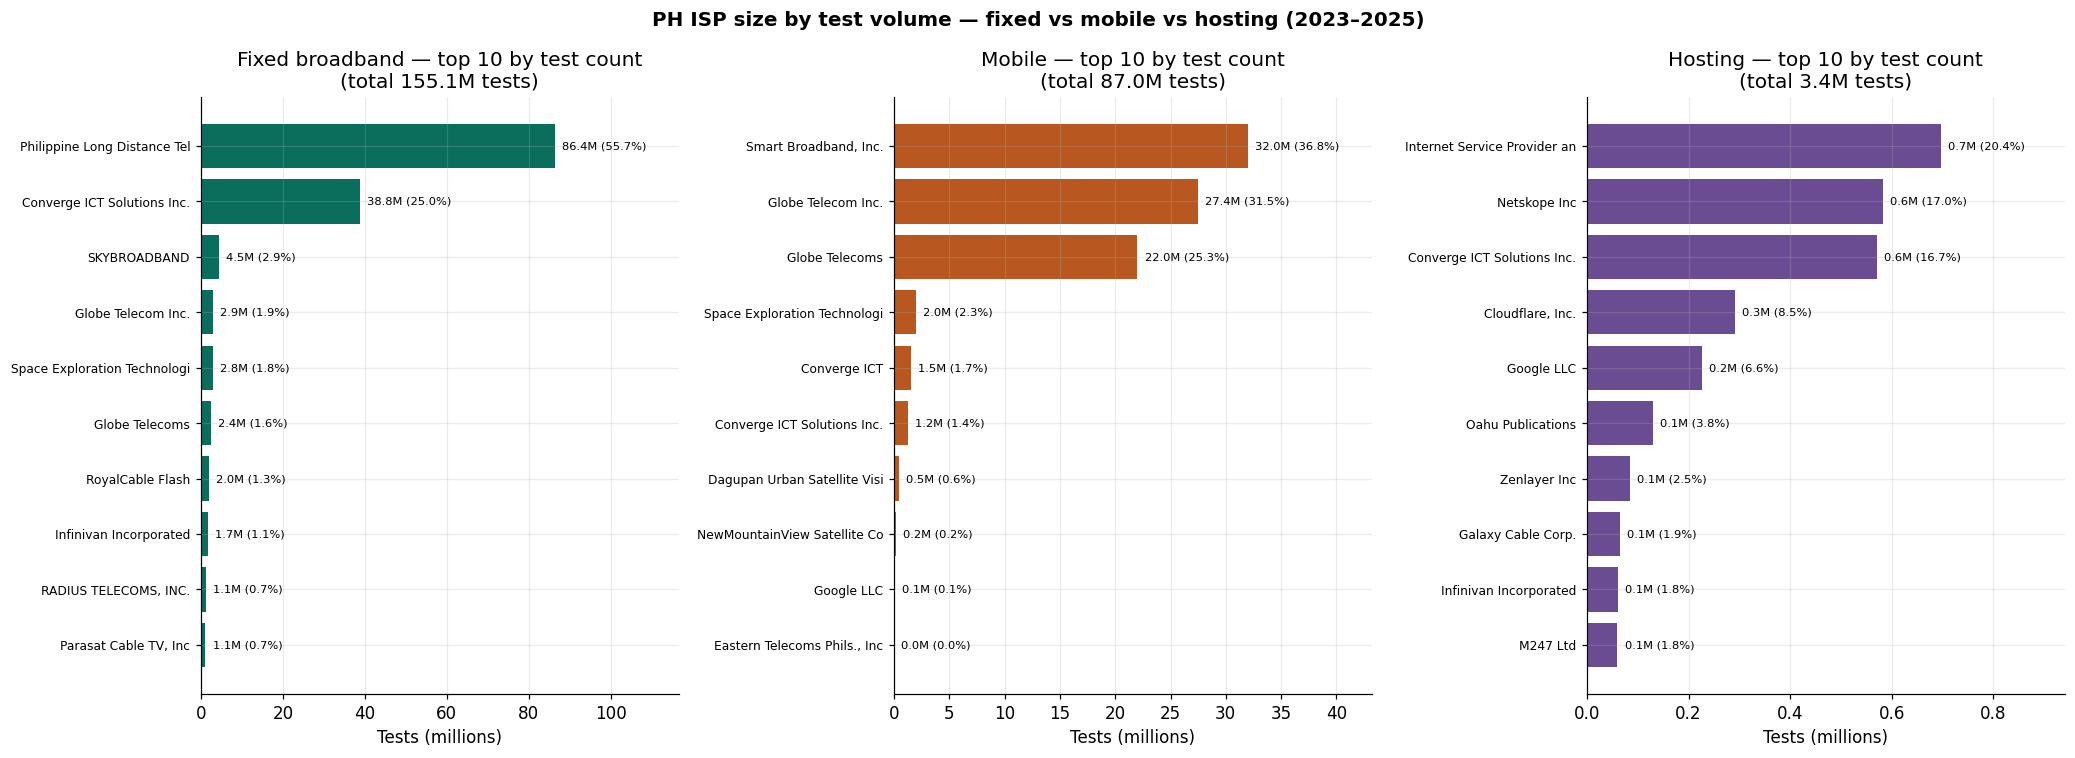


Fixed broadband — top 10 ISP
 #  ISP                                                 tests   share   unique IPs  tests/IP
--------------------------------------------------------------------------------------------
 1  Philippine Long Distance Telephone Company     86,355,876   55.7%    9,798,750       8.8
 2  Converge ICT Solutions Inc.                    38,841,251   25.0%       50,601     767.6
 3  SKYBROADBAND                                    4,474,940    2.9%      386,230      11.6
 4  Globe Telecom Inc.                              2,930,725    1.9%       41,603      70.4
 5  Space Exploration Technologies Corporation      2,824,202    1.8%        5,579     506.2
 6  Globe Telecoms                                  2,409,431    1.6%       28,567      84.3
 7  RoyalCable Flash                                2,046,681    1.3%        3,355     610.0
 8  Infinivan Incorporated                          1,662,454    1.1%        5,988     277.6
 9  RADIUS TELECOMS, INC.               

In [6]:
HOSTING = "network_type = 'hosting'"
C_HOSTING = '#6A4C93'

def isp_count_top(net_pred, topn=10):
    """Top-N ISPs by raw test volume for one network type, with unique client IPs
    alongside (tests != users: a few heavy retesters can inflate the test count)."""
    return q(f"""
        SELECT isp,
               COUNT(*)                  AS tests,
               COUNT(DISTINCT client_ip) AS uniq_ips
        FROM t
        WHERE {net_pred} AND isp IS NOT NULL
        GROUP BY 1
        ORDER BY tests DESC
        LIMIT {topn}
    """)

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
isp_counts = {}
for ax, net_pred, c, ttl in [(axes[0], FIXED,   C_FIXED,   'Fixed broadband'),
                             (axes[1], MOBILE,  C_MOBILE,  'Mobile'),
                             (axes[2], HOSTING, C_HOSTING, 'Hosting')]:
    top = isp_count_top(net_pred)
    seg_total = q(f"SELECT COUNT(*) n FROM t WHERE {net_pred} AND isp IS NOT NULL")['n'][0]
    isp_counts[ttl] = top.assign(pct=100 * top['tests'] / seg_total,
                                 tests_per_ip=top['tests'] / top['uniq_ips'])

    d = top.iloc[::-1].reset_index(drop=True)          # biggest at the top of the bar chart
    y = np.arange(len(d))
    ax.barh(y, d['tests'] / 1e6, color=c)
    mx = (d['tests'] / 1e6).max()
    for yi, r in zip(y, d.itertuples()):
        ax.text(r.tests / 1e6 + mx * 0.02, yi,
                f'{r.tests/1e6:.1f}M ({100*r.tests/seg_total:.1f}%)', va='center', fontsize=7.5)
    ax.set_yticks(y)
    ax.set_yticklabels([s[:28] for s in d['isp']], fontsize=8)
    ax.set_xlabel('Tests (millions)')
    ax.set_xlim(0, mx * 1.35)
    ax.set_title(f'{ttl} — top {len(d)} by test count\n(total {seg_total/1e6:.1f}M tests)')

fig.suptitle('PH ISP size by test volume — fixed vs mobile vs hosting (2023–2025)',
             fontweight='bold', fontsize=13)
fig.tight_layout()
plt.show()

for seg, d in isp_counts.items():
    print(f'\n{seg} — top {len(d)} ISP')
    print(f'{"#":>2}  {"ISP":<44}{"tests":>13}{"share":>8}{"unique IPs":>13}{"tests/IP":>10}')
    print('-' * 92)
    for rank, r in enumerate(d.itertuples(), 1):
        print(f'{rank:>2}  {r.isp[:43]:<44}{r.tests:>13,}{r.pct:>7.1f}%'
              f'{r.uniq_ips:>13,}{r.tests_per_ip:>10.1f}')

# Part 5 · เน็ต PH พอสำหรับแอปพลิเคชันต่าง ๆ ไหม (Table 5, Lübben & Misfeld 2022)

อ้างอิง requirement จาก [Lübben & Misfeld 2022](docs/02-ndt7-mlab/lubben-misfeld-2022-mlab-german-internet-landscape.pdf)
Table 5 — Voice 64 kbps, Video HD 5 Mbps, Video UHD 25 Mbps, Cloud gaming 44 Mbps
(**ตัด latency ออกตามที่ขอ ดูแค่ download speed**)

**วิธีวัด — ตามแบบเดียวกับ paper ต้นทาง (§5.2):** ไม่ใช้แค่ mean/median เทียบ threshold ตัวเดียว (เพราะ
distribution เบ้ขวา ค่าเฉลี่ยประเทศไม่ได้แปลว่า "ผู้ใช้ทั่วไปทำได้") แต่ดู **% ของ test ที่ทำถึง requirement นั้นจริง**
— ตรงกับที่ paper เขียนว่า "roughly half of the measurements show a throughput of 25 Mbps...
much less achieve [44 Mbps]... more than 75% of tests" achieve the HD rate

ทำแยก fixed broadband กับ mobile เพราะเป็นคนละ market/technology

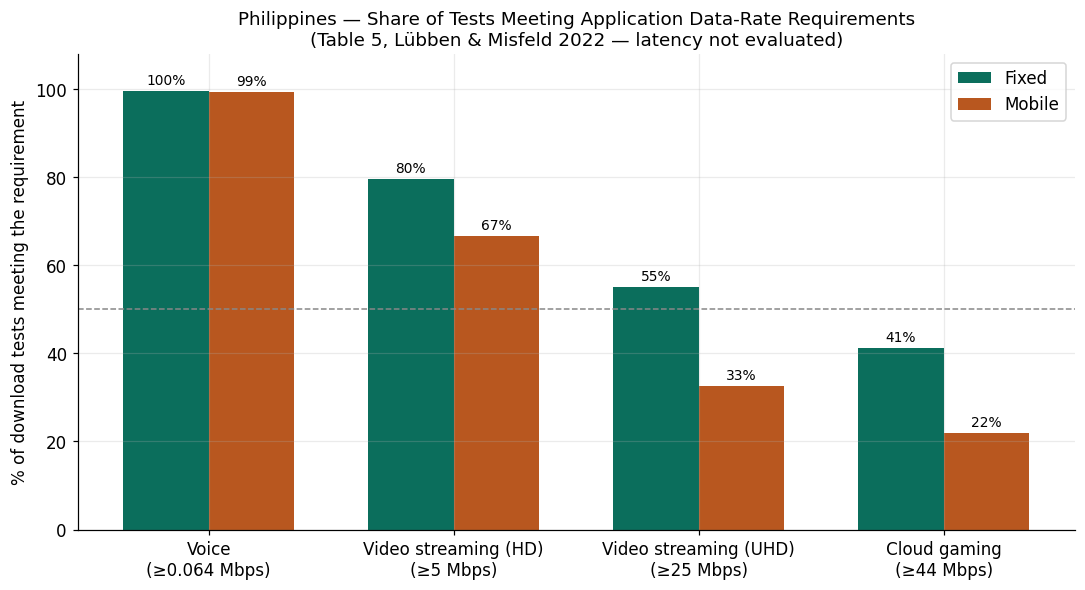

,n,mean_dl,median_dl,pct_voice,pct_hd,pct_uhd,pct_gaming
segment,,,,,,,
Mobile,55985519,38.3,10.9,99.4,66.8,32.7,21.8
Fixed,90938041,66.3,31.2,99.6,79.6,55.1,41.3


In [7]:
REQUIREMENTS = [('Voice', 0.064), ('Video streaming (HD)', 5), ('Video streaming (UHD)', 25), ('Cloud gaming', 44)]

app_pass = q(f"""
    SELECT CASE WHEN {FIXED} THEN 'Fixed' ELSE 'Mobile' END AS segment,
           COUNT(*)                                AS n,
           AVG(mean_throughput_mbps)                AS mean_dl,
           MEDIAN(mean_throughput_mbps)              AS median_dl,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=0.064 THEN 1 ELSE 0 END)/COUNT(*) AS pct_voice,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=5     THEN 1 ELSE 0 END)/COUNT(*) AS pct_hd,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=25    THEN 1 ELSE 0 END)/COUNT(*) AS pct_uhd,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=44    THEN 1 ELSE 0 END)/COUNT(*) AS pct_gaming
    FROM t
    WHERE {DL} AND ({FIXED} OR {MOBILE})
    GROUP BY 1
""").set_index('segment')

pct_cols = ['pct_voice', 'pct_hd', 'pct_uhd', 'pct_gaming']
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(REQUIREMENTS))
w = 0.35
for i, (seg, color) in enumerate([('Fixed', C_FIXED), ('Mobile', C_MOBILE)]):
    vals = app_pass.loc[seg, pct_cols].values.astype(float)
    bars = ax.bar(x + (i - 0.5) * w, vals, width=w, color=color, label=seg)
    for xi, v in zip(x + (i - 0.5) * w, vals):
        ax.text(xi, v + 1.5, f'{v:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'{name}\n(≥{req} Mbps)' for name, req in REQUIREMENTS])
ax.set_ylabel('% of download tests meeting the requirement')
ax.set_ylim(0, 108)
ax.axhline(50, ls='--', color='#888', lw=1)
ax.legend()
ax.set_title('Philippines — Share of Tests Meeting Application Data-Rate Requirements\n'
             '(Table 5, Lübben & Misfeld 2022 — latency not evaluated)', fontsize=12)
fig.tight_layout()
plt.show()

app_pass[['n', 'mean_dl', 'median_dl'] + pct_cols].round(1)

# Part 6 · เพิ่ม latency (RTT) เทียบ requirement เดียวกัน (แยกกราฟจาก Part 5)

Table 5 มี latency requirement แค่ 2 ค่าที่เป็นตัวเลขจริง — **Voice ≤200 ms** และ **Cloud gaming ≤25 ms**
(Video streaming ระบุแค่ "few seconds" ซึ่งไม่ใช่ threshold ที่วัด pass/fail ได้ เลยไม่รวมในกราฟนี้)

- ใช้ `min_rtt` จาก NDT7 (RTT วัดจาก TCP stack, round-trip ไป-กลับ) — **paper ต้นทางประมาณ one-way latency
  เป็นครึ่งหนึ่งของ RTT** ("latency, approximated with half of the RTT") จึงใช้สูตรเดียวกันตรงนี้:
  `latency ≈ min_rtt / 2`
- **ข้อควรระวัง:** นี่เป็นการประมาณคร่าว ๆ (สมมติ path สมมาตรทั้งไปและกลับ) ถ้าใช้ RTT เต็มไม่หารสอง
  % ผ่าน cloud-gaming tier จะลดลงเกือบครึ่ง (เช่น fixed 48.8% → 24.3%) — ตัวเลขในกราฟนี้ใช้สูตร**หารสอง**
  ตามที่ paper ต้นทางทำ เพื่อให้เทียบกันได้ตรง ๆ

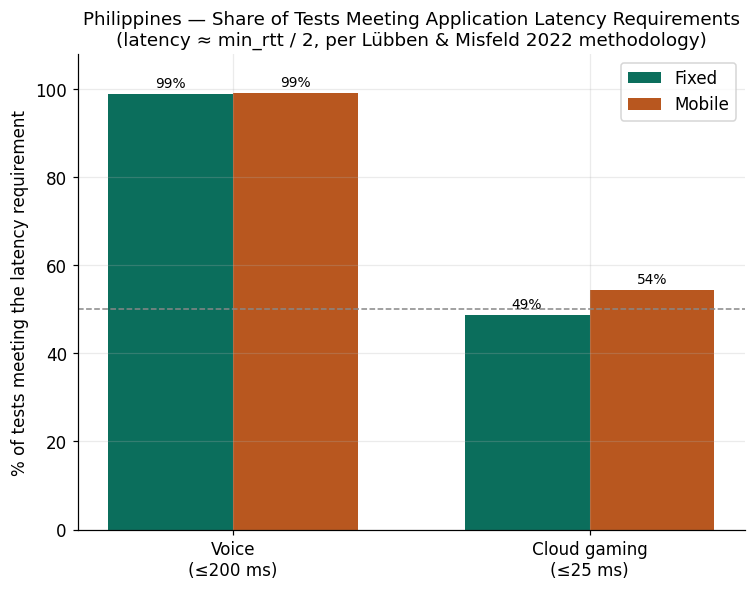

,n,mean_rtt,median_rtt,pct_voice_200,pct_gaming_25
segment,,,,,
Mobile,96192178,63.8,44.5,99.1,54.5
Fixed,161306899,68.6,51.3,98.9,48.8


In [8]:
LAT_REQUIREMENTS = [('Voice', 200), ('Cloud gaming', 25)]

rtt_pass = q("""
    SELECT CASE WHEN network_type='broadband' THEN 'Fixed' ELSE 'Mobile' END AS segment,
           COUNT(*)                                                    AS n,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END)               AS mean_rtt,
           MEDIAN(min_rtt)                                              AS median_rtt,
           100.0*SUM(CASE WHEN min_rtt/2.0 <= 200 THEN 1 ELSE 0 END)/COUNT(*) AS pct_voice_200,
           100.0*SUM(CASE WHEN min_rtt/2.0 <= 25  THEN 1 ELSE 0 END)/COUNT(*) AS pct_gaming_25
    FROM t
    WHERE network_type IN ('broadband', 'cellular') AND min_rtt IS NOT NULL AND min_rtt > 0
    GROUP BY 1
""").set_index('segment')

lat_cols = ['pct_voice_200', 'pct_gaming_25']
fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(len(LAT_REQUIREMENTS))
w = 0.35
for i, (seg, color) in enumerate([('Fixed', C_FIXED), ('Mobile', C_MOBILE)]):
    vals = rtt_pass.loc[seg, lat_cols].values.astype(float)
    ax.bar(x + (i - 0.5) * w, vals, width=w, color=color, label=seg)
    for xi, v in zip(x + (i - 0.5) * w, vals):
        ax.text(xi, v + 1.5, f'{v:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'{name}\n(≤{req} ms)' for name, req in LAT_REQUIREMENTS])
ax.set_ylabel('% of tests meeting the latency requirement')
ax.set_ylim(0, 108)
ax.axhline(50, ls='--', color='#888', lw=1)
ax.legend()
ax.set_title('Philippines — Share of Tests Meeting Application Latency Requirements\n'
             '(latency ≈ min_rtt / 2, per Lübben & Misfeld 2022 methodology)', fontsize=12)
fig.tight_layout()
plt.show()

rtt_pass[['n', 'mean_rtt', 'median_rtt'] + lat_cols].round(1)

# Part 7 · Manila – Cebu – Davao (3 จังหวัดใหญ่สุดของ PH)

3 **province** (GADM ADM1, 81 หน่วย — ไม่ใช่ region 17 หน่วย) ที่มี test volume มากสุด — Metropolitan Manila,
Cebu, Davao del Sur — บังเอิญเป็น province ตัวแทนคนละหมู่เกาะพอดี (Luzon/Visayas/Mindanao) และครอบคลุมเมืองเด่น
Quezon City/Manila/Makati, Cebu City, Davao City ตามลำดับ

metric เดียวกับที่ Part 2 ใช้กับ region (weighted avg ต่อไตรมาสแล้วเฉลี่ยข้ามไตรมาส) แต่ตรงนี้ apply กับ
**province** แทน: ค่าเฉลี่ยราย province *ต่อไตรมาส* แล้วเฉลี่ยข้าม 12 ไตรมาส (ไม่ให้ปี 2025 ที่ test เยอะกลบปีอื่น)
— แยก **fixed broadband vs mobile**, ทำทั้ง mean และ median

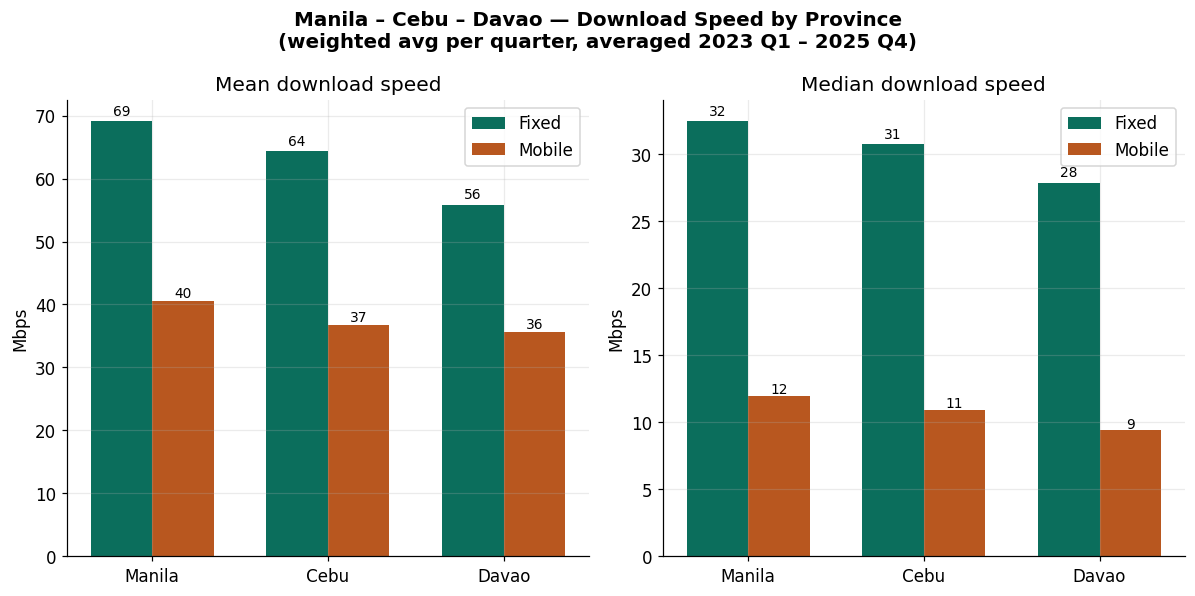

total_tests             mean_spd        median_spd       
segment              Fixed      Mobile    Fixed Mobile      Fixed Mobile
province_label                                                          
Manila          35610229.0  25655136.0     69.1   40.5       32.5   12.0
Cebu             8400156.0   5440918.0     64.3   36.7       30.7   11.0
Davao            5779777.0   3654463.0     55.8   35.7       27.9    9.4

In [9]:
BIG3 = {'MetropolitanManila': 'Manila', 'Cebu': 'Cebu', 'DavaodelSur': 'Davao'}
big3_order = ['Manila', 'Cebu', 'Davao']

big3 = q(f"""
    WITH pq AS (
        SELECT province,
               CASE WHEN {FIXED} THEN 'Fixed' ELSE 'Mobile' END AS segment,
               year, CAST(CEIL(month / 3.0) AS INT) AS quarter,
               AVG(mean_throughput_mbps)    AS q_mean,
               MEDIAN(mean_throughput_mbps) AS q_median,
               COUNT(*)                     AS q_n
        FROM t
        WHERE province IN ('MetropolitanManila', 'Cebu', 'DavaodelSur')
          AND {DL} AND ({FIXED} OR {MOBILE})
        GROUP BY 1, 2, 3, 4
    )
    SELECT province, segment,
           AVG(q_mean)   AS mean_spd,
           AVG(q_median) AS median_spd,
           SUM(q_n)      AS total_tests
    FROM pq GROUP BY 1, 2
""")
# `province` here already holds the raw GADM ADM1 name (e.g. 'MetropolitanManila'); add a
# short display label via BIG3 for axis ticks, but keep the printed table on the real name.
big3['province_label'] = big3['province'].map(BIG3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.5), sharey=False)
x = np.arange(len(big3_order))
w = 0.35
for ax, col, ttl in [(a1, 'mean_spd', 'Mean download speed'), (a2, 'median_spd', 'Median download speed')]:
    for i, (seg, color) in enumerate([('Fixed', C_FIXED), ('Mobile', C_MOBILE)]):
        d = big3[big3.segment == seg].set_index('province_label').reindex(big3_order)
        ax.bar(x + (i - 0.5) * w, d[col], width=w, color=color, label=seg)
        for xi, v in zip(x + (i - 0.5) * w, d[col]):
            ax.text(xi, v + d[col].max() * 0.015, f'{v:.0f}', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(big3_order)
    ax.set_ylabel('Mbps')
    ax.set_title(ttl)
    ax.legend()

fig.suptitle('Manila – Cebu – Davao — Download Speed by Province\n'
             '(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

big3.pivot(index='province_label', columns='segment', values=['total_tests', 'mean_spd', 'median_spd']).loc[big3_order].round(1)

# Part 8 · Manila – Cebu – Davao ตอบโจทย์แอปพลิเคชันไหน (speed, Table 5)

เหมือน Part 5 (ระดับประเทศ) แต่ตัดเฉพาะ 3 จังหวัดใหญ่ที่เลือกไว้ — ดู % ของ test ที่ทำความเร็วถึง
requirement แต่ละ tier แยกราย province (สีเดียวกับ Part 2: Manila=Luzon, Cebu=Visayas, Davao=Mindanao)
ทำแยก panel Fixed / Mobile เพราะเป็นคนละตลาด

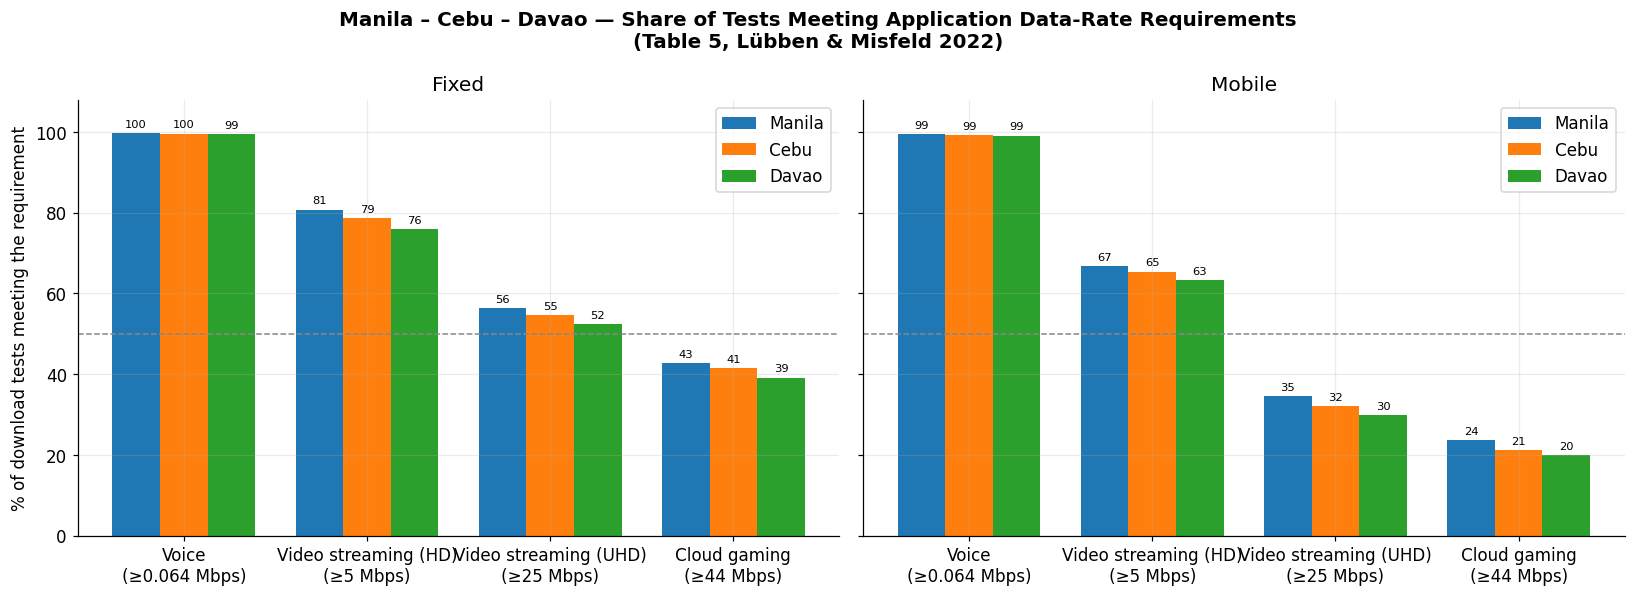

n             pct_voice        pct_hd        pct_uhd  \
segment              Fixed      Mobile     Fixed Mobile  Fixed Mobile   Fixed   
province_label                                                                  
Manila          35610229.0  25655136.0      99.6   99.4   80.7   66.8    56.3   
Cebu             8400156.0   5440918.0      99.6   99.2   78.6   65.3    54.5   
Davao            5779777.0   3654463.0      99.5   99.1   75.9   63.2    52.3   

                      pct_gaming         
segment        Mobile      Fixed Mobile  
province_label                           
Manila           34.5       42.7   23.5  
Cebu             32.0       41.5   21.1  
Davao            29.8       39.1   19.8

In [10]:
BIG3_COLORS = {'Manila': ISLAND_COLORS['Luzon'], 'Cebu': ISLAND_COLORS['Visayas'], 'Davao': ISLAND_COLORS['Mindanao']}

prov_app_pass = q(f"""
    SELECT province,
           CASE WHEN {FIXED} THEN 'Fixed' ELSE 'Mobile' END AS segment,
           COUNT(*)                                AS n,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=0.064 THEN 1 ELSE 0 END)/COUNT(*) AS pct_voice,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=5     THEN 1 ELSE 0 END)/COUNT(*) AS pct_hd,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=25    THEN 1 ELSE 0 END)/COUNT(*) AS pct_uhd,
           100.0*SUM(CASE WHEN mean_throughput_mbps>=44    THEN 1 ELSE 0 END)/COUNT(*) AS pct_gaming
    FROM t
    WHERE province IN ('MetropolitanManila', 'Cebu', 'DavaodelSur')
      AND {DL} AND ({FIXED} OR {MOBILE})
    GROUP BY 1, 2
""")
prov_app_pass['province_label'] = prov_app_pass['province'].map(BIG3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
x = np.arange(len(REQUIREMENTS))
w = 0.26
for ax, seg in [(a1, 'Fixed'), (a2, 'Mobile')]:
    d = prov_app_pass[prov_app_pass.segment == seg].set_index('province_label').reindex(big3_order)
    for i, prov in enumerate(big3_order):
        vals = d.loc[prov, pct_cols].values.astype(float)
        ax.bar(x + (i - 1) * w, vals, width=w, color=BIG3_COLORS[prov], label=prov)
        for xi, v in zip(x + (i - 1) * w, vals):
            ax.text(xi, v + 1.5, f'{v:.0f}', ha='center', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{name}\n(≥{req} Mbps)' for name, req in REQUIREMENTS])
    ax.set_title(seg)
    ax.axhline(50, ls='--', color='#888', lw=1)
    ax.legend()
a1.set_ylabel('% of download tests meeting the requirement')
a1.set_ylim(0, 108)

fig.suptitle('Manila – Cebu – Davao — Share of Tests Meeting Application Data-Rate Requirements\n'
             '(Table 5, Lübben & Misfeld 2022)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

prov_app_pass.pivot(index='province_label', columns='segment', values=['n'] + pct_cols).loc[big3_order].round(1)

# Part 9 · Manila – Cebu – Davao ตอบโจทย์แอปพลิเคชันไหน (latency, Table 5)

เหมือน Part 6 (ระดับประเทศ) แต่ตัดเฉพาะ 3 จังหวัด — latency ≈ `min_rtt / 2` เทียบ Voice (≤200ms) และ
Cloud gaming (≤25ms) เท่านั้น (Video streaming ไม่มี threshold ตัวเลขจริง)

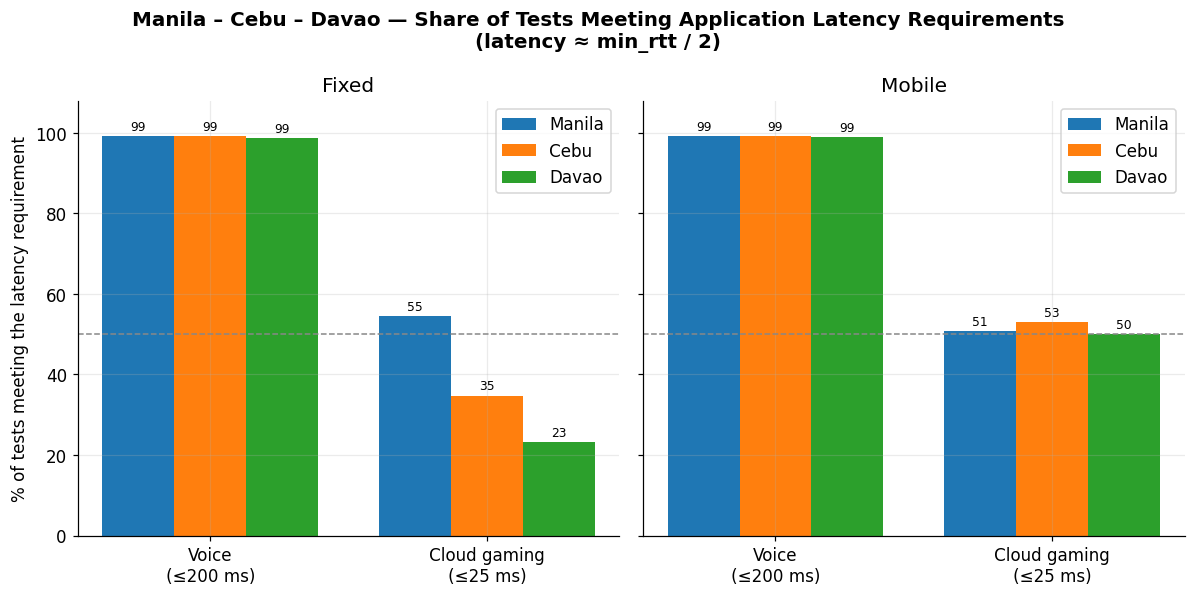

n             pct_voice_200        pct_gaming_25  \
segment              Fixed      Mobile         Fixed Mobile         Fixed   
province_label                                                              
Manila          63085242.0  43887087.0          99.1   99.1          54.5   
Cebu            15021916.0   9460616.0          99.1   99.2          34.8   
Davao           10355183.0   6360717.0          98.6   98.9          23.2   

                       
segment        Mobile  
province_label         
Manila           50.7  
Cebu             52.9  
Davao            50.0

In [11]:
prov_rtt_pass = q("""
    SELECT province,
           CASE WHEN network_type='broadband' THEN 'Fixed' ELSE 'Mobile' END AS segment,
           COUNT(*)                                                    AS n,
           100.0*SUM(CASE WHEN min_rtt/2.0 <= 200 THEN 1 ELSE 0 END)/COUNT(*) AS pct_voice_200,
           100.0*SUM(CASE WHEN min_rtt/2.0 <= 25  THEN 1 ELSE 0 END)/COUNT(*) AS pct_gaming_25
    FROM t
    WHERE province IN ('MetropolitanManila', 'Cebu', 'DavaodelSur')
      AND network_type IN ('broadband', 'cellular') AND min_rtt IS NOT NULL AND min_rtt > 0
    GROUP BY 1, 2
""")
prov_rtt_pass['province_label'] = prov_rtt_pass['province'].map(BIG3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
x = np.arange(len(LAT_REQUIREMENTS))
w = 0.26
for ax, seg in [(a1, 'Fixed'), (a2, 'Mobile')]:
    d = prov_rtt_pass[prov_rtt_pass.segment == seg].set_index('province_label').reindex(big3_order)
    for i, prov in enumerate(big3_order):
        vals = d.loc[prov, lat_cols].values.astype(float)
        ax.bar(x + (i - 1) * w, vals, width=w, color=BIG3_COLORS[prov], label=prov)
        for xi, v in zip(x + (i - 1) * w, vals):
            ax.text(xi, v + 1.5, f'{v:.0f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{name}\n(≤{req} ms)' for name, req in LAT_REQUIREMENTS])
    ax.set_title(seg)
    ax.axhline(50, ls='--', color='#888', lw=1)
    ax.legend()
a1.set_ylabel('% of tests meeting the latency requirement')
a1.set_ylim(0, 108)

fig.suptitle('Manila – Cebu – Davao — Share of Tests Meeting Application Latency Requirements\n'
             '(latency ≈ min_rtt / 2)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

prov_rtt_pass.pivot(index='province_label', columns='segment', values=['n'] + lat_cols).loc[big3_order].round(1)